# calculate gimms ndvi resilience

## import packages

In [1]:
import numpy as np
import pandas as pd

import scipy.stats
from scipy.signal import argrelmin
from scipy.optimize import curve_fit
import scipy.stats as st

import numpy.ma as ma
import glob

import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import xarray as xr

In [3]:
## 准备数据
def prep_ts(ts_data, time_data):
    doy = [x for x in time_data]  # time.data为nc的时间维度，类型为datatime64 然后索引x【0】将列表里的时间拿出来转为Timestamp
    ts_use = pd.Series(ts_data, index=doy)
    return ts_use

## 计算resilience
def calc_ar1(x):
    return ma.corrcoef(ma.masked_invalid(x[:-1]), ma.masked_invalid(x[1:]))[0,1]

def compute_lam(x, dt=1):
    dx = (x[1:] - x[:-1]) / dt
    x0 = x[:-1]
    mask = ~np.isnan(x0) & ~np.isnan(dx)
    return st.linregress(x0[mask], dx[mask])[0]

def compute_sigma(x, dt=1):
    dx = (x[1:] - x[:-1]) / dt
    lamb = compute_lam(x, dt)
    diff = dx - lamb * x[:-1]
    return np.nanstd(diff) * np.sqrt(dt)

## 去除长期和季节趋势: 滑动平均去长期趋势   harmonic去季节趋势
def harmonic_fit(ser, order=3):
    import statsmodels.api as sm
    harm_freq = list(range(1, order+1))
    
    x, y = ser.index, ser.values
    
    # x = x / 365.25
    # x_rad = x * 2 * np.pi #Convert days to radians for harmonic fitting

    x = np.array([(xi - pd.Timestamp('1970-01-01')).days for xi in x]) / 365.25
    x_rad = x * 2 * np.pi #Convert days to radians for harmonic fitting
    
    #Create empty array to hold the independents
    nr_indep = order*2 + 2
    indep = np.empty((y.shape[0], nr_indep))
    
    #Add constant for intercept and then time
    indep[:,0] = 1
    indep[:,1] = x_rad
    
    #Now create the harmonic variables
    i = 2
    for freq in harm_freq:
        cos = np.cos(x_rad * freq)
        sin = np.sin(x_rad * freq)
        indep[:,i] = cos
        i = i + 1
        indep[:,i] = sin
        i = i + 1
        
    model = sm.OLS(y, indep, missing='drop').fit()
    coefs = model.params
    fitted = []
    for t in range(x_rad.shape[0]):
        data = indep[t,:]
        harm_term = np.nansum(coefs*data)
        fitted.append(harm_term)
    fitted = np.array(fitted)
    return pd.Series(ser.values - fitted, index=ser.index)

##滑动平均
def runmean(x, w):
    n = x.shape[0]
    xs = np.zeros_like(x)
    for i in range(w // 2):
        xs[i] = np.nanmean(x[: i + w // 2 + 1])
    for i in range(n - w // 2, n):
        xs[i] = np.nanmean(x[i - w // 2 + 1:])
    for i in range(w // 2, n - w // 2):
        xs[i] = np.nanmean(x[i - w // 2 : i + w // 2 + 1])
    return x - xs

## 滑动平局后进行谐波拟合去趋势
def deseason_detrend(ser, yrs=5, yl=24):
    rm_offline = pd.Series(runmean(ser.values, yrs*yl), index=ser.index)
    deseason_rolling = harmonic_fit(rm_offline, order=3)
    return deseason_rolling

## 计算恢复力
def resilience_calc(res_ts):
    lambda_var, lambda_ac1= np.nan, np.nan

    try:
        if calc_ar1(res_ts.values) < 0:
            lambda_ac1 = -999
        else:
            lambda_ac1 = np.log(calc_ar1(res_ts.values))    
        var = np.nanvar(res_ts.values)
        sigma = compute_sigma(res_ts.values)
        if sigma**2/var > 1:
            lambda_var = -999
        else:
            lambda_var = 0.5 * np.log(1-sigma**2 / var)
    except Exception as e:
        print('像元为空')
    
    return lambda_var, lambda_ac1

In [4]:
## 定义空间恢复力计算函数，用于xarray.apply_ufunc()
def spatial_resilience(ts, time_ar):
    if np.isnan(ts).all() :
        resilience = (np.nan, np.nan)
    else:
        ser = prep_ts(ts, time_ar)
        res = deseason_detrend(ser, yrs=5, yl=24)
        resilience = resilience_calc(res)
    return resilience

In [5]:
## 读取landcover数据
with xr.open_dataset(r'F:/modis_landcover/landcover_gimms_mask.nc').modis_landcover as ld:
    landCover = ld
landCover

<xarray.DataArray 'modis_landcover' (lat: 2160, lon: 4320)>
[9331200 values with dtype=float64]
Coordinates:
    year     int64 ...
  * lat      (lat) float64 89.96 89.88 89.79 89.71 ... -89.79 -89.88 -89.96
  * lon      (lon) float64 -180.0 -179.9 -179.8 -179.7 ... 179.8 179.9 180.0

## 读取ndvi数据  
### 分成四份做

In [6]:
gimms_path = glob.glob(r'F:/gimms_3g_2022/*.nc4')
len(gimms_path)

82

In [7]:
with xr.open_dataset('F:/gimms_3g_2022/ndvi3g_geo_v1_1_1982_0106.nc4') as gimms_n:
    gimms_exam = gimms_n

gimms_exam 

<xarray.Dataset>
Dimensions:     (time: 12, nv: 2, lon: 4320, lat: 2160)
Coordinates:
  * time        (time) datetime64[ns] 1982-01-08 1982-01-24 ... 1982-06-23
  * lon         (lon) float64 -180.0 -179.9 -179.8 -179.7 ... 179.8 179.9 180.0
  * lat         (lat) float64 89.96 89.88 89.79 89.71 ... -89.79 -89.88 -89.96
Dimensions without coordinates: nv
Data variables:
    crs         int32 ...
    time_bnds   (time, nv) datetime64[ns] ...
    satellites  (time) float32 ...
    ndvi        (time, lat, lon) float32 ...
    percentile  (time, lat, lon) float32 ...
Attributes: (12/19)
    publisher_type:         institution
    publisher_institution:  Oak Ridge National Laboratory Distributed Active ...
    publisher_url:          daac.ornl.gov
    publisher_email:        uso@daac.ornl.gov
    filename:               ndvi3g_geo_v1_1_1982_0106.nc4
    institution:            NASA/GSFC GIMMS
    ...                     ...
    southernmost_latitude:  -90
    westernmost_longitude:  -180
    easternmost_longitude:  180
    reference:              Pinzon, J.E. and C.J. Tucker. 2014. A Non-Station...
    comments:               Version 1.1 includes three major fixes (a- c), an...
    Conventions:            CF-1.6

(array([9.6838048e+07, 9.2678520e+06, 9.7399000e+04, 0.0000000e+00,
        2.9592890e+06, 1.4834230e+06, 1.7994000e+04, 0.0000000e+00,
        1.1725740e+06, 1.3782100e+05]),
 array([   0.,  500., 1000., 1500., 2000., 2500., 3000., 3500., 4000.,
        4500., 5000.]),
 <BarContainer object of 10 artists>)

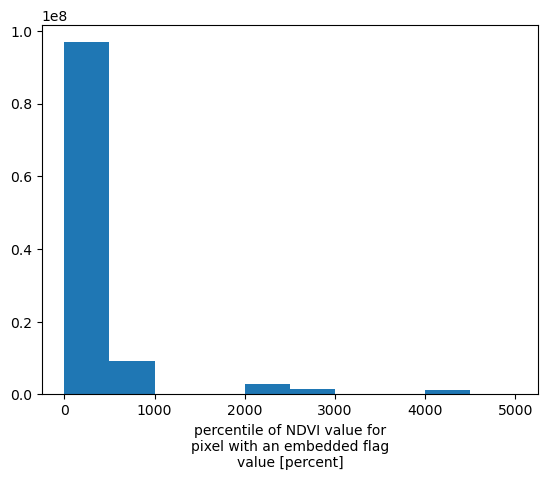

In [8]:
gimms_exam.percentile.plot.hist()

In [9]:
gimms_ndvi = []
for gimms_path_n in gimms_path:
    print(gimms_path_n)
    with  xr.open_dataset(gimms_path_n).sel(lon = slice(-180,-90))  as gimms_n:
        gimms_ndvi.append(gimms_n['ndvi'].where(gimms_n['percentile'] <= 2000))

gimms_ndvi = xr.concat(gimms_ndvi, dim='time')



F:/gimms_3g_2022\ndvi3g_geo_v1_1_1982_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1982_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1983_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1983_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1984_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1984_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1985_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1985_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1986_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1986_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1987_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1987_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1988_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1988_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1989_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1989_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1990_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1990_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1991_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1991_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1992_0106.nc4
F:/gimms_3g_2

In [10]:
gimms_ndvi

<xarray.DataArray 'ndvi' (time: 984, lat: 2160, lon: 1080)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1982-01-08 1982-01-24 ... 2022-12-24
  * lon      (lon) float64 -180.0 -179.9 -179.8 -179.7 ... -90.21 -90.13 -90.04
  * lat      (lat) float64 89.96 89.88 89.79 89.71 ... -89.79 -89.88 -89.96
Attributes:
    units:          1
    scale:          x 10000
    valid_range:    [-0.3  1. ]
    standard_name:  normalized_difference_vegetation_index
    long_name:      maximum normalized difference vegetation index (NDVI) ove...
    description:    pixels with ndvi = -5000 should be treated as missing data

(array([4.00000e+00, 1.95679e+05, 1.72200e+03, 5.07240e+04, 7.03530e+04,
        3.88610e+04, 2.27010e+04, 1.06760e+04, 4.72300e+03, 1.91800e+03]),
 array([-5000., -3514., -2028.,  -542.,   944.,  2430.,  3916.,  5402.,
         6888.,  8374.,  9860.]),
 <BarContainer object of 10 artists>)

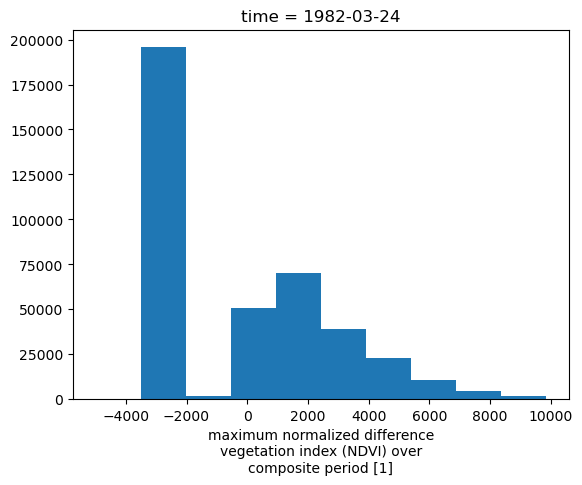

In [11]:
gimms_ndvi[5].plot.hist()

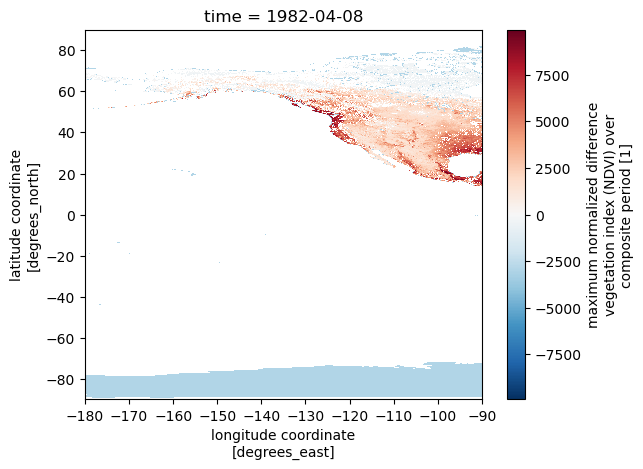

In [12]:
gimms_ndvi[6].plot()

In [13]:
gimms_ndvi = gimms_ndvi*0.0001

In [14]:
gimms_ndvi = gimms_ndvi.where(gimms_ndvi>=0)

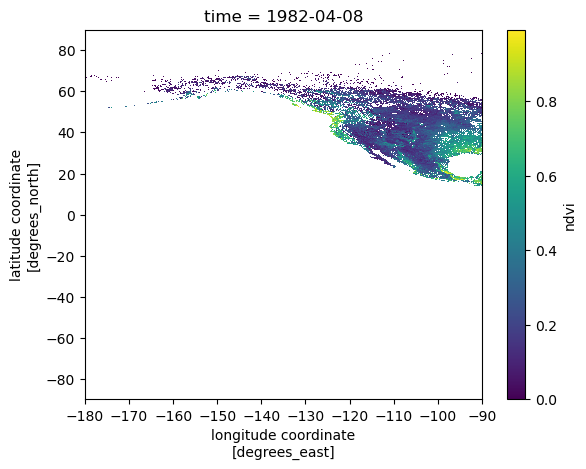

In [15]:
gimms_ndvi[6].plot()

In [16]:
gimms_ndvi_point = gimms_ndvi.sel(lat=40, lon=-110, method='nearest')

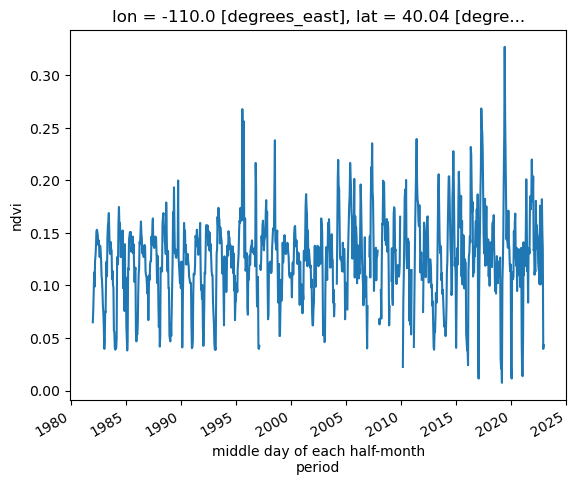

In [17]:
gimms_ndvi_point.plot()

In [19]:
spatial_resilience(gimms_ndvi_point, gimms_ndvi.time.values)

(-0.5314213703330617, -0.5340223901383956)

In [21]:
## 定义空间恢复力计算函数，用于xarray.apply_ufunc()
def spatial_resilience(ts):
    if np.isnan(ts).all() :
        resilience = (np.nan, np.nan)
    else:
        ser = prep_ts(ts, gimms_ndvi.time.values)
        res = deseason_detrend(ser, yrs=5, yl=24)
        resilience = resilience_calc(res)
    return resilience

In [22]:
resilience_result1 =  xr.apply_ufunc(
    spatial_resilience,
    gimms_ndvi,
    input_core_dims=[['time']],
    output_core_dims=[[],[]],
    vectorize= True
)

像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空


In [23]:
resilience_result1

(<xarray.DataArray 'ndvi' (lat: 2160, lon: 1080)>
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]])
 Coordinates:
   * lon      (lon) float64 -180.0 -179.9 -179.8 -179.7 ... -90.21 -90.13 -90.04
   * lat      (lat) float64 89.96 89.88 89.79 89.71 ... -89.79 -89.88 -89.96,
 <xarray.DataArray 'ndvi' (lat: 2160, lon: 1080)>
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]])
 Coordinates:
   * lon      (lon) float64 -180.0 -179.9 -179.8 -179.7 ... -90.21 -90.13 -90.04
   * lat      (lat) float64 89.96 89.88 89.79 89.71 ... -89.79 -

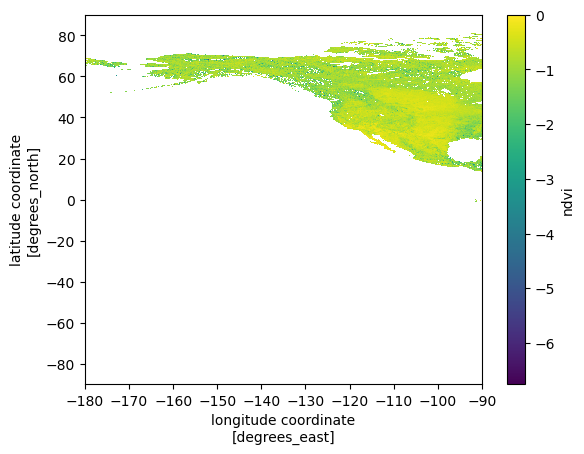

In [24]:
var_1, ac1_1 = resilience_result1
var_1.where(var_1 != -999).plot()

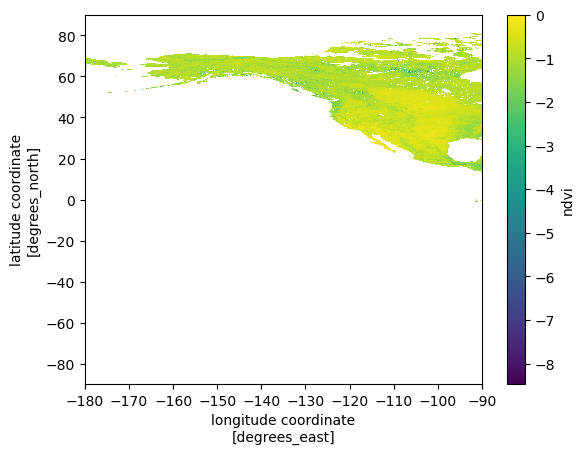

In [25]:
ac1_1.where(ac1_1 != -999).plot()

In [44]:
var_1 = var_1.where(landCover.sel(lon=slice(-180,-90)) >0 )
ac1_1 = ac1_1.where(landCover.sel(lon=slice(-180,-90)) >0 )

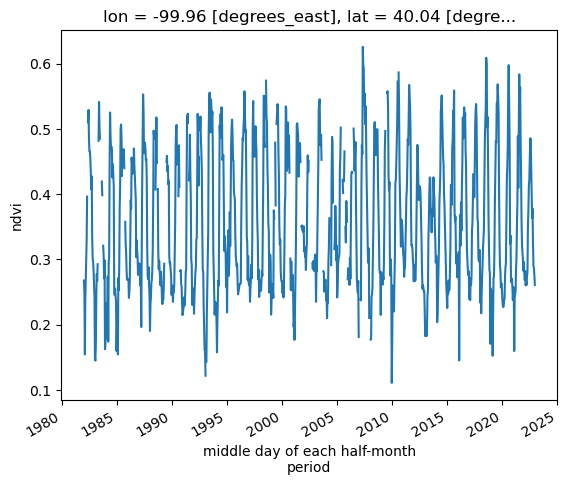

In [26]:
gimms_ndvi_point = gimms_ndvi.sel(lat=40, lon=-100, method='nearest')
gimms_ndvi_point.plot()

In [27]:
gimms_ndvi_point_ts = prep_ts(gimms_ndvi_point.values, gimms_ndvi_point.time.values)

In [28]:
res_gimms = deseason_detrend(gimms_ndvi_point_ts, yrs=5, yl=24)

<Axes: >

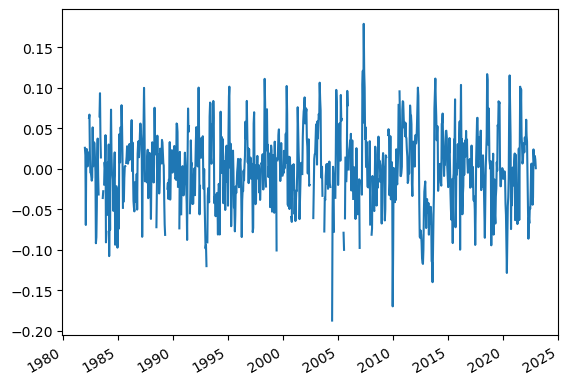

In [30]:
res_gimms.plot()

In [31]:
gimms_ndvi = []
for gimms_path_n in gimms_path:
    print(gimms_path_n)
    with  xr.open_dataset(gimms_path_n).sel(lon = slice(-90,0))  as gimms_n:
        gimms_ndvi.append(gimms_n['ndvi'].where(gimms_n['percentile'] <= 2000))

gimms_ndvi = xr.concat(gimms_ndvi, dim='time')

F:/gimms_3g_2022\ndvi3g_geo_v1_1_1982_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1982_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1983_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1983_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1984_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1984_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1985_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1985_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1986_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1986_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1987_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1987_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1988_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1988_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1989_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1989_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1990_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1990_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1991_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1991_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1992_0106.nc4
F:/gimms_3g_2

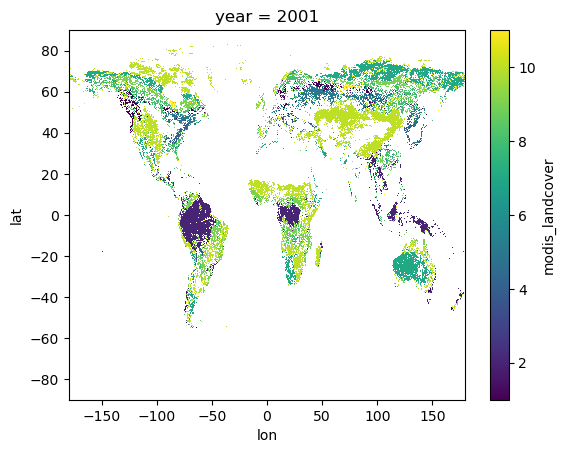

In [32]:
landCover.plot()

In [33]:
gimms_ndvi = gimms_ndvi*0.0001
gimms_ndvi = gimms_ndvi.where(gimms_ndvi>=0)
gimms_ndvi = gimms_ndvi.where(landCover.sel(lon=slice(-90,0))>=0)

In [38]:
gimms_ndvi

<xarray.DataArray 'ndvi' (time: 984, lat: 2160, lon: 1080)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1982-01-08 1982-01-24 ... 2022-12-24
  * lon      (lon) float64 -89.96 -89.88 -89.79 ... -0.2083 -0.125 -0.04167
  * lat      (lat) float64 89.96 89.88 89.79 89.71 ... -89.79 -89.88 -89.96
    year     int64 ...

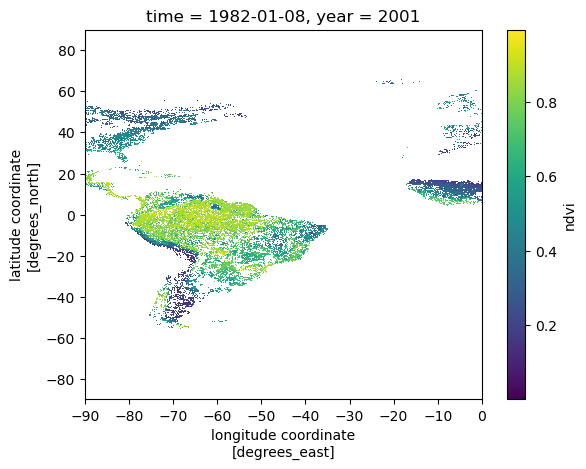

In [34]:
gimms_ndvi[0].plot()

In [35]:
resilience_result2 =  xr.apply_ufunc(
    spatial_resilience,
    gimms_ndvi,
    input_core_dims=[['time']],
    output_core_dims=[[],[]],
    vectorize= True
)

像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空
像元为空


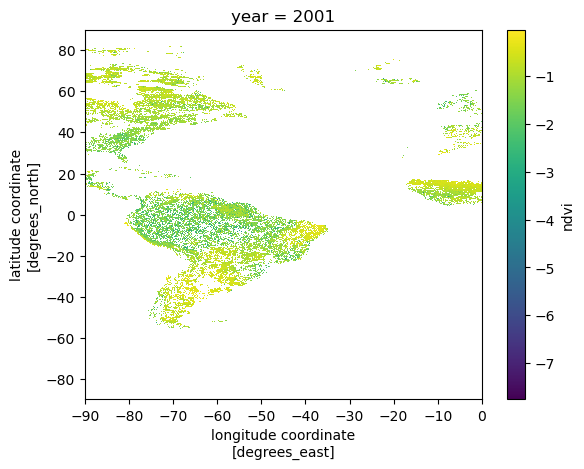

In [36]:
var_2, ac1_2 = resilience_result2
var_2.where(var_2 != -999).plot()

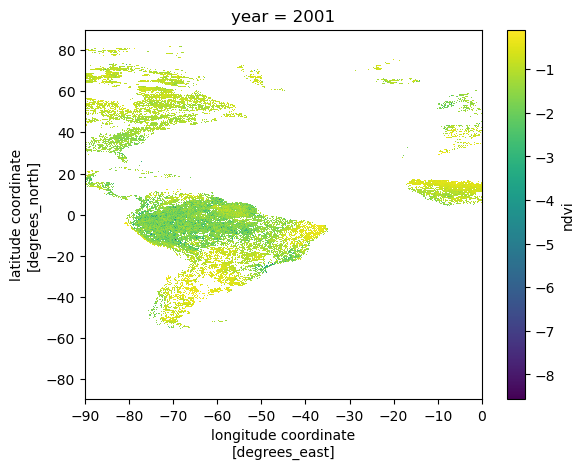

In [37]:
ac1_2.where(ac1_2 != -999).plot()

In [39]:
gimms_ndvi = []
for gimms_path_n in gimms_path:
    print(gimms_path_n)
    with  xr.open_dataset(gimms_path_n).sel(lon = slice(0,90))  as gimms_n:
        gimms_ndvi.append(gimms_n['ndvi'].where(gimms_n['percentile'] <= 2000))

gimms_ndvi = xr.concat(gimms_ndvi, dim='time')

F:/gimms_3g_2022\ndvi3g_geo_v1_1_1982_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1982_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1983_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1983_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1984_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1984_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1985_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1985_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1986_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1986_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1987_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1987_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1988_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1988_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1989_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1989_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1990_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1990_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1991_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1991_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1992_0106.nc4
F:/gimms_3g_2

In [40]:
gimms_ndvi = gimms_ndvi*0.0001
gimms_ndvi = gimms_ndvi.where(gimms_ndvi>=0)
gimms_ndvi = gimms_ndvi.where(landCover.sel(lon=slice(0,90))>=0)

In [41]:
resilience_result3 =  xr.apply_ufunc(
    spatial_resilience,
    gimms_ndvi,
    input_core_dims=[['time']],
    output_core_dims=[[],[]],
    vectorize= True
)

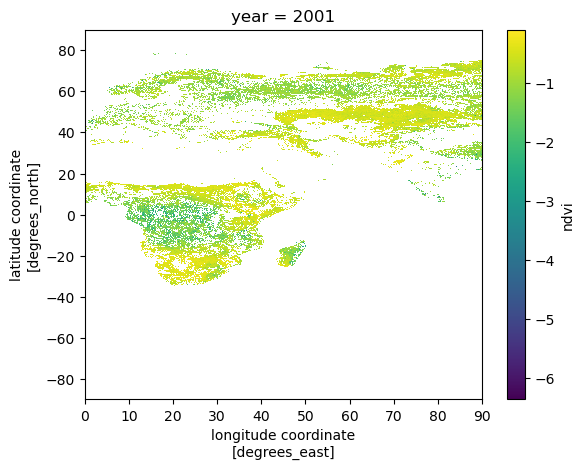

In [42]:
var_3, ac1_3 = resilience_result3
var_3.where(var_3 != -999).plot()

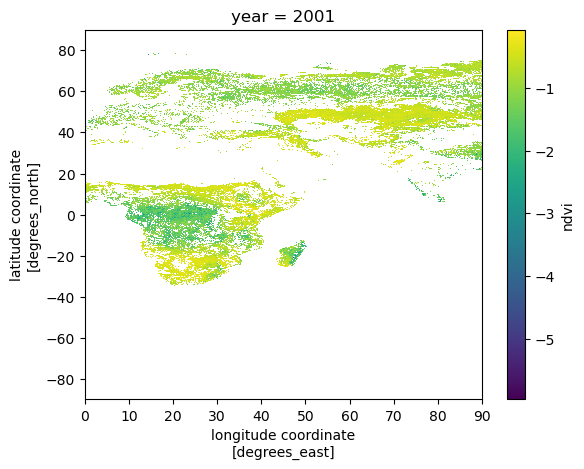

In [43]:
ac1_3.where(ac1_3 != -999).plot()

In [45]:
var_18090 = xr.concat([var_1,var_2,var_3], dim='lon')
ac1_18090 = xr.concat([ac1_1,ac1_2,ac1_3], dim='lon')

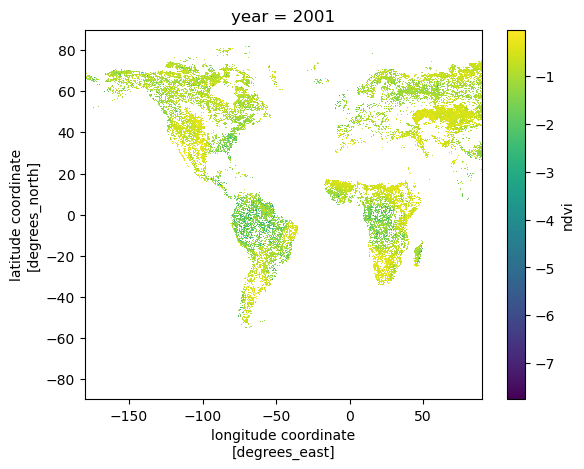

In [47]:
var_18090.where(var_18090 != -999).plot()

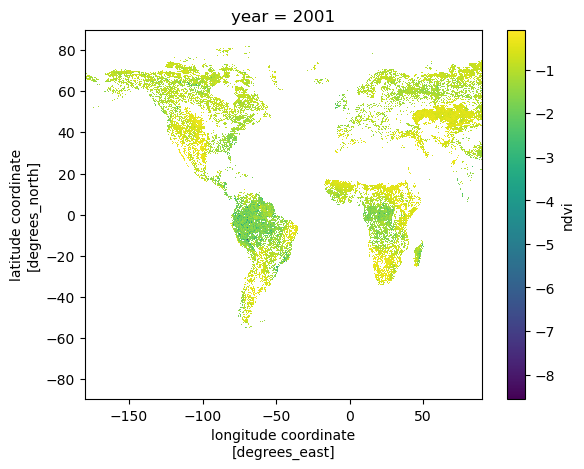

In [48]:
ac1_18090.where(ac1_18090 != -999).plot()

In [50]:
var_18090.name = 'var'
ac1_18090.name = 'ac1'

In [52]:
var_18090.to_netcdf("D:/var_18090.nc")
ac1_18090.to_netcdf("D:/ac1_18090.nc")

In [53]:
gimms_ndvi = []
for gimms_path_n in gimms_path:
    print(gimms_path_n)
    with  xr.open_dataset(gimms_path_n).sel(lon = slice(90,180))  as gimms_n:
        gimms_ndvi.append(gimms_n['ndvi'].where(gimms_n['percentile'] <= 2000))

gimms_ndvi = xr.concat(gimms_ndvi, dim='time')

F:/gimms_3g_2022\ndvi3g_geo_v1_1_1982_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1982_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1983_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1983_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1984_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1984_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1985_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1985_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1986_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1986_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1987_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1987_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1988_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1988_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1989_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1989_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1990_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1990_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1991_0106.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1991_0712.nc4
F:/gimms_3g_2022\ndvi3g_geo_v1_1_1992_0106.nc4
F:/gimms_3g_2

In [54]:
gimms_ndvi = gimms_ndvi*0.0001
gimms_ndvi = gimms_ndvi.where(gimms_ndvi>=0)
gimms_ndvi = gimms_ndvi.where(landCover.sel(lon=slice(90,180))>=0)

In [55]:
resilience_result4 =  xr.apply_ufunc(
    spatial_resilience,
    gimms_ndvi,
    input_core_dims=[['time']],
    output_core_dims=[[],[]],
    vectorize= True
)

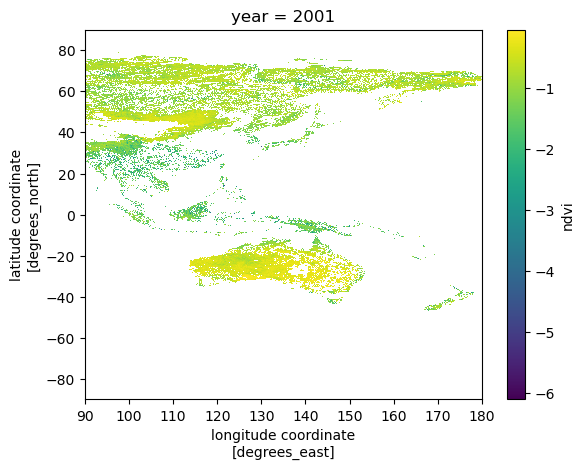

In [56]:
var_4, ac1_4 = resilience_result4
var_4.where(var_4 != -999).plot()

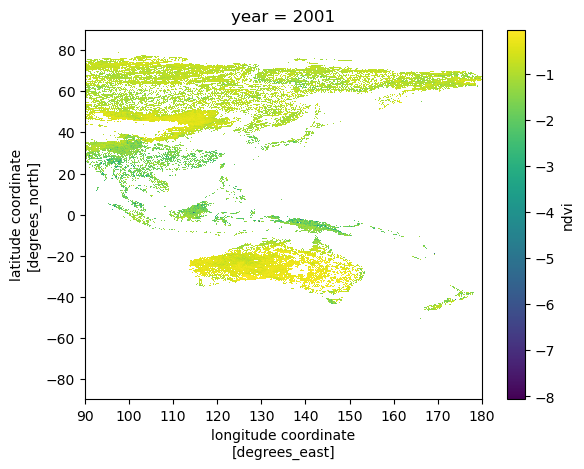

In [57]:
ac1_4.where(ac1_4 != -999).plot()

In [58]:
var_global = xr.concat([var_18090,var_4], dim='lon')
ac1_global = xr.concat([ac1_18090,ac1_4], dim='lon')

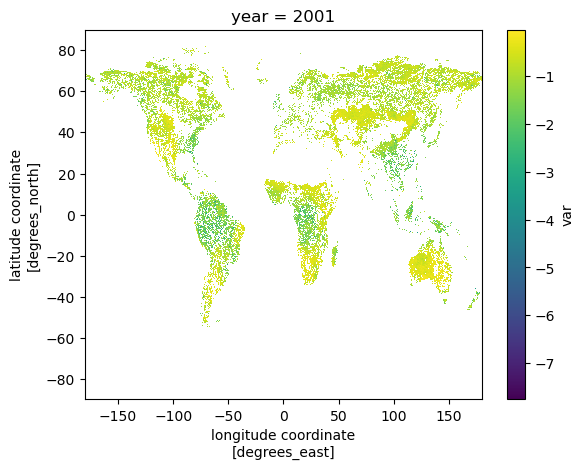

In [60]:
var_global.where(var_global !=-999).plot()

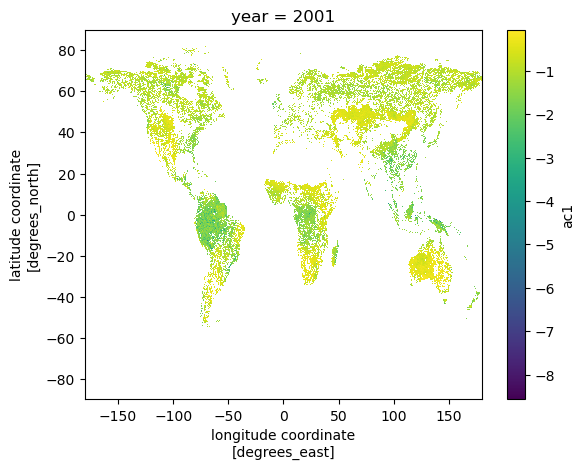

In [61]:
ac1_global.where(ac1_global !=-999).plot()

In [67]:
var_global.to_netcdf(r"D:/code/python_file/geo/var_gimms_global.nc")
ac1_global.to_netcdf(r"D:/code/python_file/geo/ac1_gimms_global.nc")

In [63]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

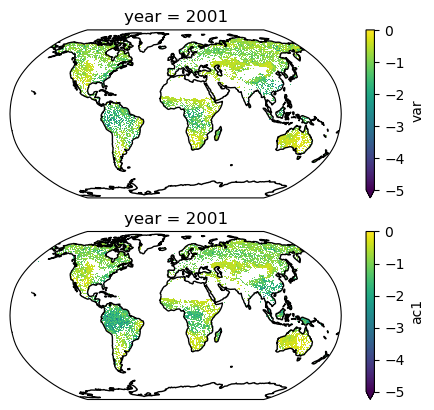

In [66]:
fig= plt.figure()

ax1 = fig.add_subplot(2, 1, 1,projection=ccrs.Robinson())
ax2 = fig.add_subplot(2, 1, 2,projection=ccrs.Robinson())

var_global.where(var_global != -999).plot( ax=ax1,transform=ccrs.PlateCarree(), vmin=-5, vmax = 0, robust=True)
ac1_global.where(ac1_global != -999).plot( ax=ax2,transform=ccrs.PlateCarree(), vmin=-5, vmax = 0, center = False, robust=True)
ax1.coastlines()
ax2.coastlines()